In [1]:
# importing libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, datasets
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# Feed-forward Neural Network Model

The feed-forward neural network is defined as follows:

$$
\begin{equation}
    \begin{split}
        \boldsymbol{a}^{[0]} &= \boldsymbol{x}\\
        \boldsymbol{a}^{[l+1]} &= \boldsymbol{\sigma}\left(W^{[l+1]}\boldsymbol{a}^{[l]} + \boldsymbol{b}^{[l+1]}\right)\,,\quad \quad l=0:L-1
    \end{split}
\end{equation}
$$

where $\boldsymbol{x}\in\mathbb{R}^{n_1}$ is a data point, $\boldsymbol{b}^{[l+1]}$ is the bias vector at layer $l$, $W^{[l+1]}$ is the weight matrix applied at layer $l+1$, and $L$ is the total number of layers.

$\boldsymbol{\sigma}:\mathbb{R}^{n_l}\rightarrow\mathbb{R}^{n_l}$ is the nonlinear activation function, applied component-wise.

For any $l=0:L-1\,$,

$$
\begin{align*}
    &\boldsymbol{z}^{[l+1]} = W^{[l+1]}\boldsymbol{a}^{[l]} + \boldsymbol{b}^{[l+1]}\\
    \implies &\boldsymbol{a}^{[l+1]} = \boldsymbol{\sigma}(\boldsymbol{z}^{[l+1]})
\end{align*}
$$

In [2]:
# implementing deep neural network
class MLP(nn.Module):
    def __init__(self, in_features=10, hidden_features=10, out_features=2, num_layers=50):
        super(MLP, self).__init__()
        
        self.layers = nn.ModuleList()
        
        # Layer 1: Linear
        self.layers.append(nn.Linear(in_features=in_features, out_features=hidden_features))
        
        # Layers 2 to L-1: Linear
        for _ in range(num_layers - 2):
            self.layers.append(nn.Linear(in_features=hidden_features, out_features=hidden_features))
            
        # Layer L: Linear Output
        self.layers.append(nn.Linear(in_features=hidden_features, out_features=out_features))

    def forward(self, x):
        # flatten the input
        x = x.view(x.size(0), -1)

        # Layer 1 to L-1: Linear -> Tanh
        for i in range(len(self.layers) - 1):
            x = F.tanh(self.layers[i](x))
            
        # Layer L: Output Layer
        x = self.layers[-1](x)
        
        return x

The total loss function $\mathcal{L}$ is a function of the true class labels $y_{i}$ and the network outputs $\boldsymbol{a}^{[L]}_i$ over all data points.

# Backpropagation

To train the network, the weights are updated using gradient-based optimizers such as stochastic gradient descent or Adam. This requires computing the gradient of the loss function with respect to the parameters via the backpropagation chain rule.

The gradient of the loss function with respect to $\boldsymbol{b}^{[l]}$ is given by
$$
\begin{align*}
    \frac{\partial \mathcal{L}}{\partial \boldsymbol{b}^{[l]}} = \frac{\partial \mathcal{L}}{\partial\boldsymbol{a}^{[L]}} \cdot \frac{\partial\boldsymbol{a}^{[L]}}{\partial \boldsymbol{a}^{[L-1]}}\dots\frac{\partial \boldsymbol{a}^{[l+1]}}{\partial \boldsymbol{a}^{[l]}}\cdot\frac{\partial \boldsymbol{a}^{[l]}}{\partial \boldsymbol{b}^{[l]}}
\end{align*}
$$

Here,

$$
\begin{align*}
    \frac{\partial\boldsymbol{a}^{[l+1]}}{\partial \boldsymbol{a}^{[l]}} = \text{diag}(\sigma'(\boldsymbol{z}^{[l+1]})) W^{[l+1]}
\end{align*}
$$

# Vanishing Gradient Problem

To find the gradient of the loss function with respect to the parameters in an earlier layer, we can observe that the per-layer Jacobians are continuously multiplied across the depth of the network. The gradient reaching layer $l$ is therefore a product of $L-l$ such Jacobians.

Now, if $|\sigma'(t)|<1$ and the weight matrices have spectral norm of order $1$ or less, then each factor in this product has norm less than $1$, so the product decays with depth. As a result, the gradient norm $\|\partial\mathcal{L}/\partial W^{[l]}\|$ is smaller for early layers (small $l$) than for layers near the output. This is the **vanishing gradient problem**.

<!-- It is important to note that this is a phenomenon across **layers (depth)**, not across training **epochs (time)**: the decay is present even at initialization, before any optimization step is taken. Its consequence over training is that the early layers receive a near-zero gradient signal at every step, so they are barely updated and the network fails to optimize the early parameters efficiently. -->

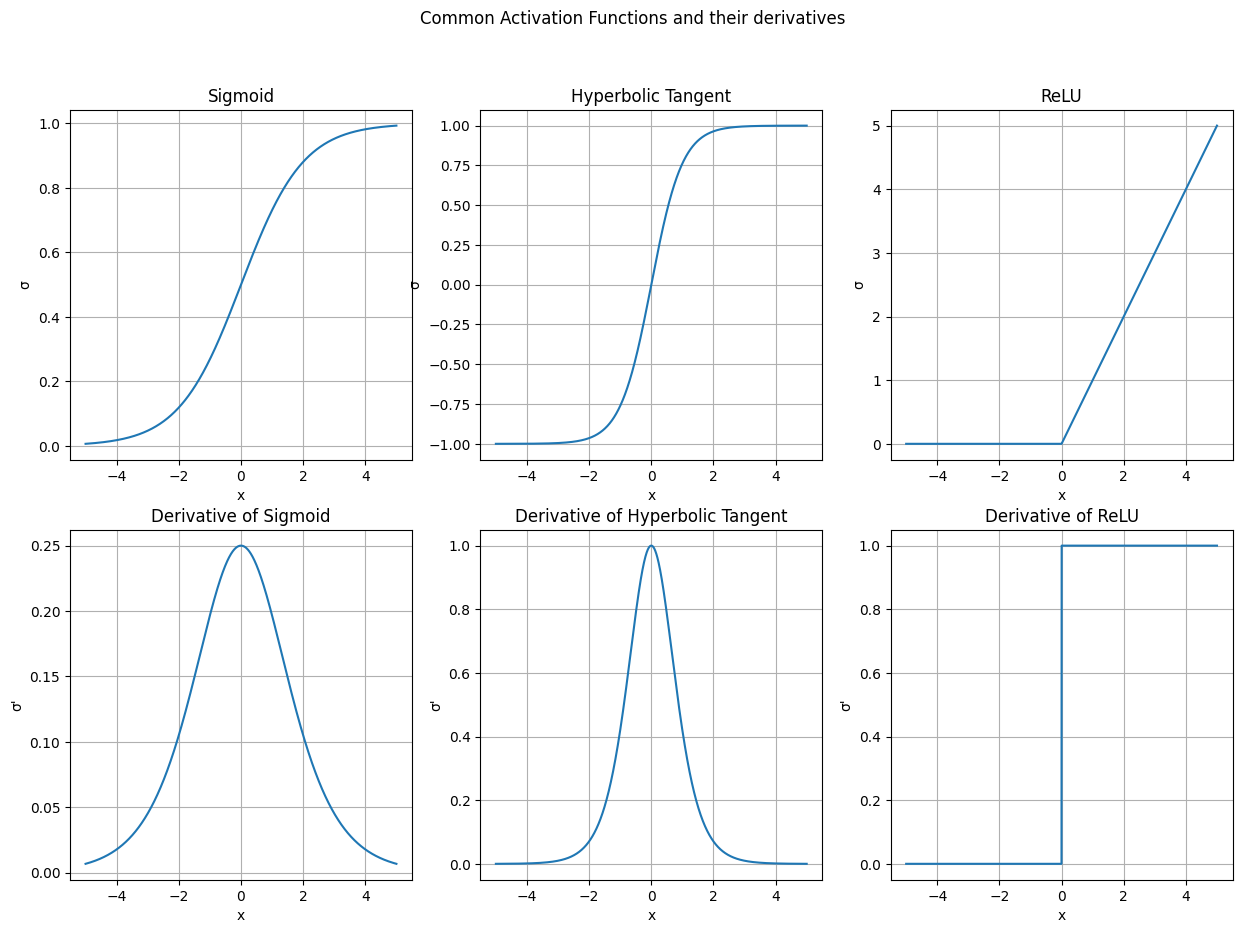

In [3]:
# plotting common activations and their derivatives
fig, ax = plt.subplots(nrows=2,ncols=3,figsize=(15,10))
grid = torch.linspace(-5,5,2000)

ax[0,0].plot(grid.numpy(),nn.Sigmoid()(grid))
ax[0,0].set_title("Sigmoid")
ax[0,0].grid(True)
ax[0,0].set_xlabel("x")
ax[0,0].set_ylabel("σ")

ax[0,1].plot(grid.numpy(),nn.Tanh()(grid))
ax[0,1].set_title("Hyperbolic Tangent")
ax[0,1].grid(True)
ax[0,1].set_xlabel("x")
ax[0,1].set_ylabel("σ")

ax[0,2].plot(grid.numpy(),nn.ReLU()(grid))
ax[0,2].set_title("ReLU")
ax[0,2].grid(True)
ax[0,2].set_xlabel("x")
ax[0,2].set_ylabel("σ")

ax[1,0].plot(grid.numpy(),nn.Sigmoid()(grid)*(1-nn.Sigmoid()(grid)))
ax[1,0].set_title("Derivative of Sigmoid")
ax[1,0].grid(True)
ax[1,0].set_xlabel("x")
ax[1,0].set_ylabel("σ'")


ax[1,1].plot(grid.numpy(),1-(nn.Tanh()(grid))**2)
ax[1,1].set_title("Derivative of Hyperbolic Tangent")
ax[1,1].grid(True)
ax[1,1].set_xlabel("x")
ax[1,1].set_ylabel("σ'")


ax[1,2].plot(grid.numpy(), torch.where(grid < 0, 0.0, 1.0))
ax[1,2].set_title("Derivative of ReLU")
ax[1,2].grid(True)
ax[1,2].set_xlabel("x")
ax[1,2].set_ylabel("σ'")

plt.suptitle("Common Activation Functions and their derivatives")
plt.show()

For instance, 

$$
\begin{align*}
    ||\frac{\partial\boldsymbol{a}^{[l+1]}}{\partial \boldsymbol{a}^{[l]}}||_2 &\leq ||\text{diag}(\sigma'(\boldsymbol{z}^{[l+1]}))||_2||W^{[l+1]}||_2\\
    &=\left(\max_{i}|[\text{diag}(\sigma'(\boldsymbol{z}^{[l+1]}))]_{ii}|\right)||W^{[l+1]}||_2\\
    &\leq 1
\end{align*}
$$

The early layers receive a near-zero gradient signal at every step, so they are barely updated and the network fails to optimize the parameters efficiently.

This phenomenon is illustrated below on both the Two-Moons and MNIST datasets.

## Two-Moons Dataset

In [52]:
# generate the two-moons dataset using scikit-learn
X, y = make_moons(n_samples=1000, noise=0.12)

# convert data to tensors with appropriate dtypes
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

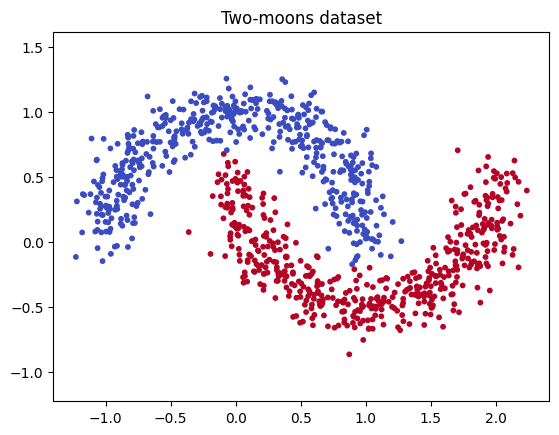

In [53]:
# plot the two-moons dataset
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=10)
plt.title("Two-moons dataset")
plt.axis("equal")
plt.show()

In [54]:
X.shape, y.shape

(torch.Size([1000, 2]), torch.Size([1000]))

In [55]:
# splitting dataset into training and test
X_train, X_test, y_train, y_test = train_test_split(X.numpy(), y.numpy(), test_size=0.2)

# convert data points to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test,  dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test  = torch.tensor(y_test,  dtype=torch.long)

In [56]:
# loading the data into batches
dataset = TensorDataset(X_train, y_train)
trainloader = DataLoader(dataset, batch_size=64, shuffle=True)

# extracting a single batch for experimenting
X_batch, y_batch = next(iter(trainloader))

In [57]:
# a single forward and backward pass
# Multi-layer perceptron
model = MLP(in_features=2, hidden_features=10, out_features=2, num_layers=50)

# Forward pass
output = model(X_batch)
loss_function = nn.CrossEntropyLoss()
loss = loss_function(output, y_batch)

# Backward pass
loss.backward()

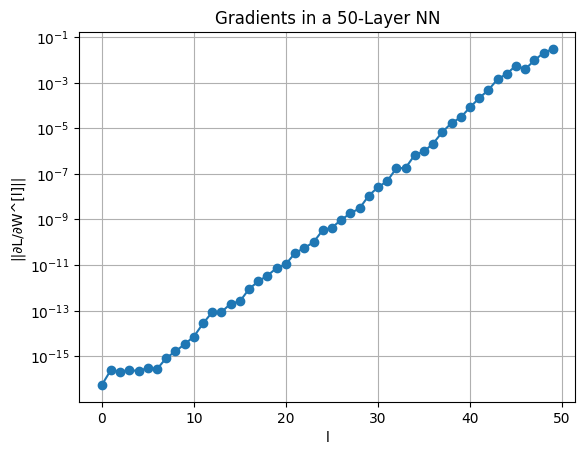

In [58]:
# collecting the norm of the gradients
gradient_norms = []
for layer in model.layers:
    norm = layer.weight.grad.norm().item()  # Extract gradient norms for each layer
    gradient_norms.append(norm)

# plot the gradient norm with respect to layer depth
plt.plot(gradient_norms, marker='o')
plt.title("Gradients in a 50-Layer NN")
plt.xlabel("l")
plt.ylabel(f"||∂L/∂W^[l]||")
plt.yscale("log")
plt.grid(True)
plt.show()

As is evident from the plot above, the gradient norm is substantially smaller in the earlier layers; consequently, those layers learn little from the data.

## MNIST Dataset

In [59]:
# defining transforms to normalize MNIST data
transform = transforms.Compose([transforms.ToTensor(), 
                            transforms.Normalize((0.5,), (0.5,))])

# downloading and extracting training MNIST dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_dataset.data.shape

torch.Size([60000, 28, 28])

In [60]:
# loading the data into batches
trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

# extracting a single batch for experimenting
images, labels = next(iter(trainloader))

In [61]:
# a single forward and backward pass
# Multi-layer perceptron
model = MLP(in_features=784, hidden_features=10, out_features=10,num_layers=50)
loss_function = nn.CrossEntropyLoss()

# Forward pass
output = model(images)
loss = loss_function(output, labels)

# Backward pass
loss.backward()

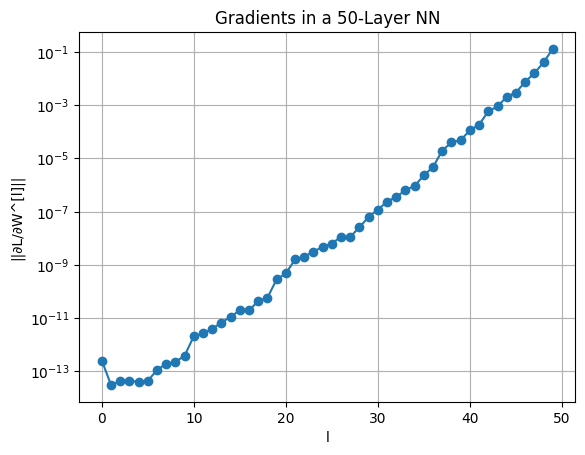

In [62]:
# collecting the norm of the gradients
gradient_norms = []
for layer in model.layers:
    norm = layer.weight.grad.norm().item()      # extract gradient norms for each layer
    gradient_norms.append(norm)

# plot the gradient norm with respect to layer depth
plt.plot(gradient_norms, marker='o')
plt.title("Gradients in a 50-Layer NN")
plt.xlabel("l")
plt.ylabel(f"||∂L/∂W^[l]||")
plt.yscale("log")
plt.grid(True)
plt.show()

The same vanishing-gradient phenomenon is observed on the MNIST dataset.

# ResNet

The residual network (ResNet) architecture is defined as follows:

$$
\begin{equation}
    \begin{split}
        \boldsymbol{a}^{[0]} &= \boldsymbol{x}\\
        \boldsymbol{a}^{[l+1]} &= \boldsymbol{a}^{[l]}+\boldsymbol{\sigma}\left(W^{[l+1]}\boldsymbol{a}^{[l]} + \boldsymbol{b}^{[l+1]}\right)\,,\quad \quad l=0:L-1
    \end{split}
\end{equation}
$$

where $\boldsymbol{x}\in\mathbb{R}^{n_1}$ is a data point, $\boldsymbol{b}^{[l+1]}$ is the bias vector at layer $l$, $W^{[l+1]}$ is the weight matrix applied at layer $l+1$, and $L$ is the total number of layers.

Let $\boldsymbol{\mathcal{F}}(\boldsymbol{a}^{[l]};\boldsymbol{\theta}^{[l]}) = \boldsymbol{\sigma}(W^{[l+1]}\boldsymbol{a}^{[l]} + \boldsymbol{b}^{[l+1]})$ with parameters $\boldsymbol{\theta}^{[l]} = (W^{[l+1]}, \boldsymbol{b}^{[l+1]})$ where $l=0:L-1\,$.

A standard feed-forward network learns the map

$$
\boldsymbol{a}^{[l+1]} = \boldsymbol{\mathcal{F}}(\boldsymbol{a}^{[l]};\boldsymbol{\theta}^{[l]})
$$

whereas a ResNet learns a residual update
$$
\boldsymbol{a}^{[l+1]} = \boldsymbol{a}^{[l]} + \boldsymbol{\mathcal{F}}(\boldsymbol{a}^{[l]};\boldsymbol{\theta}^{[l]})
$$

**Backpropagation in ResNet.**

The gradient of the loss function with respect to $\boldsymbol{b}^{[l]}$ is given by
$$
\begin{align*}
    \frac{\partial \mathcal{L}}{\partial \boldsymbol{b}^{[l]}} = \frac{\partial \mathcal{L}}{\partial\boldsymbol{a}^{[L]}} \cdot \frac{\partial\boldsymbol{a}^{[L]}}{\partial \boldsymbol{a}^{[L-1]}}\dots\frac{\partial \boldsymbol{a}^{[l+1]}}{\partial \boldsymbol{a}^{[l]}}\cdot\frac{\partial \boldsymbol{a}^{[l]}}{\partial \boldsymbol{b}^{[l]}}
\end{align*}
$$

where 
$$
\begin{align*}
    \frac{\partial\boldsymbol{a}^{[l+1]}}{\partial \boldsymbol{a}^{[l]}} = I+\text{diag}(\sigma'(\boldsymbol{z}^{[l+1]})) W^{[l+1]}
\end{align*}
$$

It follows that

$$
\begin{align*}
    \frac{\partial \mathcal{L}}{\partial \boldsymbol{b}^{[l]}} = \frac{\partial \mathcal{L}}{\partial\boldsymbol{a}^{[L]}} + \frac{\partial \mathcal{L}}{\partial\boldsymbol{a}^{[L]}}\sum\left(\text{Cross-terms}\right)
\end{align*}
$$

The gradient from the final layer propagates directly to layer $l$ without attenuation. This structural modification preserves a strong gradient signal and mitigates the training difficulties characteristic of very deep networks.

In [63]:
# implementing ResNet
class ResNet(nn.Module):
    def __init__(self, in_features=10, hidden_features=10, out_features=2, num_layers=50):
        super(ResNet, self).__init__()
        
        self.layers = nn.ModuleList()
        
        # Layer 1: Linear
        self.layers.append(nn.Linear(in_features=in_features, out_features=hidden_features))
        
        # Layers 2 to L-1: Linear
        for _ in range(num_layers - 2):
            self.layers.append(nn.Linear(in_features=hidden_features, out_features=hidden_features))
            
        # Layer L: Linear Output
        self.layers.append(nn.Linear(in_features=hidden_features, out_features=out_features))

    def forward(self, x):
        # flatten the input
        x = x.view(x.size(0), -1)

        # Layer 1: Linear -> Tanh
        x = F.tanh(self.layers[0](x))
        
        # Layer 2 to L-1: Linear -> Tanh
        for i in range(1,len(self.layers) - 1):
            x = x + F.tanh(self.layers[i](x))              # Adding Skip connections
            
        # Layer L: Output Layer
        x = self.layers[-1](x)
        
        return x

## Two-Moons Dataset

In [64]:
# a single forward and backward pass
# Multi-layer ResNet
model = ResNet(in_features=2, hidden_features=10, out_features=2, num_layers=50)

# Forward pass
output = model(X_batch)
loss_function = nn.CrossEntropyLoss()
loss = loss_function(output, y_batch)

# Backward pass
loss.backward()

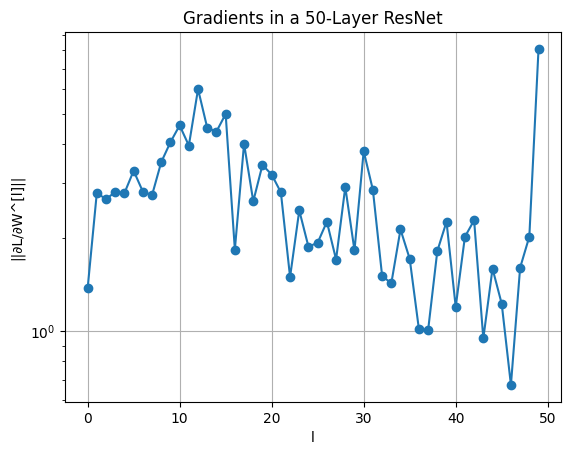

In [65]:
# collecting the norm of the gradients
gradient_norms = []
for layer in model.layers:
    norm = layer.weight.grad.norm().item()      # extract gradient norms for each layer
    gradient_norms.append(norm)

# plot the gradient norm with respect to layer depth
plt.plot(gradient_norms, marker='o')
plt.title("Gradients in a 50-Layer ResNet")
plt.xlabel("l")
plt.ylabel(f"||∂L/∂W^[l]||")
plt.yscale("log")
plt.grid(True)
plt.show()

The ResNet model mitigates the vanishing-gradient problem in deep networks, as illustrated in the plot above.

## MNIST Dataset

In [66]:
# a single forward and backward pass
# deep ResNet model
model = ResNet(in_features=784, hidden_features=128, out_features=10,num_layers=50)

# Use CrossEntropyLoss for classification (combines LogSoftmax and NLLLoss)
loss_function = nn.CrossEntropyLoss()

# Forward pass
output = model(images)
loss = loss_function(output, labels)

# Backward pass
loss.backward()

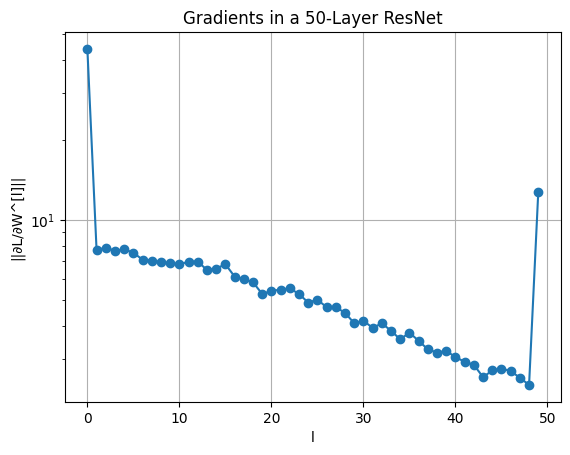

In [67]:
# collecting the norm of the gradients
gradient_norms = []
for layer in model.layers:
    norm = layer.weight.grad.norm().item()          # extract gradient norms for each layer
    gradient_norms.append(norm)

# display results
plt.plot(gradient_norms, marker='o')
plt.title("Gradients in a 50-Layer ResNet")
plt.xlabel("l")
plt.ylabel(f"||∂L/∂W^[l]||")
plt.yscale("log")
plt.grid(True)
plt.show()

# Comparison of Accuracies on the Two-Moons Dataset

Here, we compare the performance of a plain deep neural network and a deep ResNet on the Two-Moons dataset.

In [68]:
# training loop
def training_loop(model, X_train, y_train, X_test, y_test, epochs=100, lr=1e-2):

    # Adam optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # cross-entropy loss
    loss_function = nn.CrossEntropyLoss()


    losses = []
    for _ in range(epochs):
        # reset gradients
        optimizer.zero_grad()

        # computing loss
        loss = loss_function(model(X_train), y_train)

        # backpropagate to compute gradients
        loss.backward()

        # optimizer step
        optimizer.step()

        # record the loss for this epoch
        losses.append(loss.item())

    # evaluate train and test accuracy
    with torch.no_grad():
        train_accuracy = (model(X_train).argmax(1) == y_train).float().mean().item()
        test_accuracy  = (model(X_test).argmax(1)  == y_test).float().mean().item()
        
    return losses, train_accuracy, test_accuracy

In [69]:
# train a deep plain neural network
neural_net = MLP(in_features=2, hidden_features=10, out_features=2, num_layers=50)
loss_nn, train_accuracy_nn, test_accuracy_nn = training_loop(neural_net, X_train, y_train, X_test, y_test)

# train a deep residual network
res_net = ResNet(in_features=2, hidden_features=10, out_features=2, num_layers=50)
loss_res, train_accuracy_resnet, test_accuracy_resnet = training_loop(res_net, X_train, y_train, X_test, y_test)

# Printing the performce of both the models
print("-"*50)
print("Plain Neural Network with 50 layers")
print(f"Train accuracy: {train_accuracy_nn*100:.2f}%\nTest accuracy: {test_accuracy_nn*100:.2f}%")

print("-"*50)
print("ResNet with 50 layers")
print(f"Train accuracy: {train_accuracy_resnet*100:.2f}%\nTest accuracy: {test_accuracy_resnet*100:.2f}%")

--------------------------------------------------
Plain Neural Network with 50 layers
Train accuracy: 50.25%
Test accuracy: 49.00%
--------------------------------------------------
ResNet with 50 layers
Train accuracy: 100.00%
Test accuracy: 99.50%


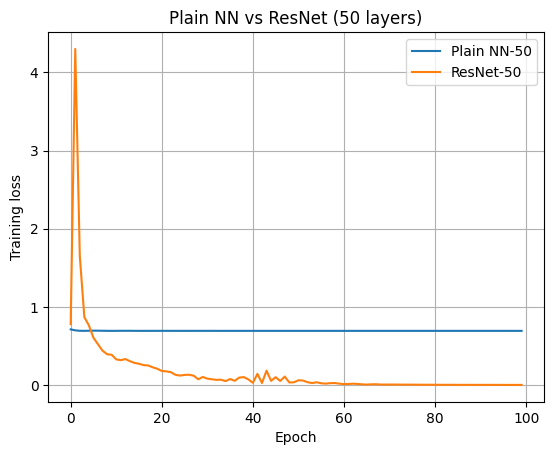

In [70]:
# plot training loss for both models
plt.plot(loss_nn, label=f"Plain NN-50")
plt.plot(loss_res,   label=f"ResNet-50")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Plain NN vs ResNet (50 layers)")
plt.legend()
plt.grid(True)
plt.show()

The ResNet model achieves high accuracy and trains more efficiently than the plain neural network, whose loss saturates early.

# Continuous-Time Limit: Neural ODEs

The standard ResNet updates are given by:

$$
\begin{align*}
    \boldsymbol{a}^{[l+1]} = \boldsymbol{a}^{[l]} + \boldsymbol{\mathcal{F}}(\boldsymbol{a}^{[l]};\boldsymbol{\theta}^{[l]})
\end{align*}
$$

Associate each layer index $l$ with a continuous depth $t = l\,\Delta t$, and introduce an explicit step size $\Delta t$:

$$
\boldsymbol{a}^{[l+1]} = \boldsymbol{a}^{[l]} + \Delta t\boldsymbol{\mathcal{F}}(\boldsymbol{a}^{[l]};\boldsymbol{\theta}^{[l]}).
$$

The standard ResNet is recovered when $\Delta t = 1$. Rearranging the terms, we get

$$
\frac{\boldsymbol{a}^{[l+1]} - \boldsymbol{a}^{[l]}}{\Delta t} = \boldsymbol{\mathcal{F}}(\boldsymbol{a}^{[l]};\boldsymbol{\theta}^{[l]}).
$$

Now, identifying the layer index $l$ with a continuous "depth" variable $t$ and taking the limit $\Delta t \to 0$, the left-hand side becomes a derivative and the discrete state $\boldsymbol{a}^{[l]}$ becomes a continuous trajectory $\boldsymbol{a}(t)$:

$$
\boxed{\ \frac{d\boldsymbol{a}(t)}{dt} = \boldsymbol{\mathcal{F}}(\boldsymbol{a}(t), t;\theta),\qquad \boldsymbol{a}(0) = \boldsymbol{x}.\ }
$$


Starting from the input $\boldsymbol{a}(0)$, we define the output $\boldsymbol{a}(T)$ as the solution of this ordinary differential equation (ODE) initial-value problem at time $T$. This solution may be computed by a numerical ODE solver that evaluates the dynamics $\boldsymbol{\mathcal{F}}$ as needed to achieve the desired accuracy.

In other words, a deep residual network is a **forward Euler discretization** of an ODE, and the network "depth" corresponds to the integration interval $[0,T]$. This is the **Neural ODE** viewpoint: rather than stacking a fixed number of layers, one specifies the dynamics $\boldsymbol{\mathcal{F}}$ and delegates integration to an ODE solver.

## Neural ODE Model and Training Loop


The model predicts the state at a target time $T$ by evaluating an Initial Value Problem (IVP) solver:

$$
\begin{align*}
    \boldsymbol{a}(T) &= \boldsymbol{a}(0)+\int_0^T \boldsymbol{\mathcal{F}}(\boldsymbol{a}(t),t;\boldsymbol{\theta})\,dt
\end{align*}
$$


**Training Loop:**

- **Forward pass**: Specify an initial state $\boldsymbol{a}(0)$ and integrate the dynamics $\mathcal{F}$ with an ODE solver, which approximates $\boldsymbol{a}(T)$ via intermediate steps. For example, forward Euler with four steps on $[0,1]$ proceeds as follows:

$$
\begin{align*}
    \boldsymbol{a}(0.25) &= \boldsymbol{a}(0.00)+\frac{1}{4}\mathcal{F}(\boldsymbol{a}(0.00),0.00;\boldsymbol{\theta})\\
    \boldsymbol{a}(0.50) &= \boldsymbol{a}(0.25)+\frac{1}{4}\mathcal{F}(\boldsymbol{a}(0.25),0.25;\boldsymbol{\theta})\\
    \boldsymbol{a}(0.75) &= \boldsymbol{a}(0.50)+\frac{1}{4}\mathcal{F}(\boldsymbol{a}(0.50),0.50;\boldsymbol{\theta})\\
    \boldsymbol{a}(1.00) &= \boldsymbol{a}(0.75)+\frac{1}{4}\mathcal{F}(\boldsymbol{a}(0.75),0.75;\boldsymbol{\theta})
\end{align*}
$$

- **Loss computation**: Pass the final state $\boldsymbol{a}(T)$ through a classifier and compute the loss (e.g., cross-entropy) between the prediction and the true label $y$. Supervision is provided only by the label, not by a target trajectory.

- **Backward pass**: Compute the gradients $\partial\mathcal{L}/\partial\boldsymbol{\theta}$. In the demonstration below, we backpropagate through the solver using standard autograd. In practice, the adjoint sensitivity method is often preferred: it solves a backward-in-time ODE for the gradients and avoids storing the full forward trajectory, yielding $O(1)$ memory complexity in depth.

- **Optimization**: Update the parameters $\boldsymbol{\theta}$ of $\boldsymbol{\mathcal{F}}$ using a standard optimizer (e.g., SGD or Adam).

For each training pair $(\boldsymbol{x}_i, y_i)$, set $\boldsymbol{a}(0)=\boldsymbol{x}_i$, integrate to obtain $\boldsymbol{a}(T)$, classify the result, and evaluate the loss against $y_i$. The parameters $\boldsymbol{\theta}$ are then updated by gradient descent to minimize the aggregate loss.

At test time, the same ODE is integrated from each new input.

## Training a Neural ODE (2D demonstration)

To demonstrate learning with a Neural ODE, we train a model on a two-dimensional two-moons classification task. Each input point serves as the initial condition $\boldsymbol{a}(0)=\boldsymbol{x}$; the learned dynamics $\boldsymbol{\mathcal{F}}$ are integrated to time $T$ using a fixed-step **forward Euler** solver, and a linear layer classifies the terminal state $\boldsymbol{a}(T)$. Gradients are computed by standard autograd through the solver (without the adjoint method or an external ODE library).

In [71]:
# defining an ODE integrator (solver)
@torch.no_grad()
def integrate_ode(f, a, T, N, method="euler"):
    """Integrate da/dt = f(a) on [0, T] with N steps (euler or rk4)."""
    # time step
    dt = T / N

    for _ in range(N):

        # forward-Euler integrator
        if method == "euler":
            a = a + dt * f(a)

        # RK4 integrator    
        elif method == "rk4":
            k1 = f(a)
            k2 = f(a + 0.5 * dt * k1)
            k3 = f(a + 0.5 * dt * k2)
            k4 = f(a + dt * k3)
            a = a + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
    return a

In [87]:
# implementing Neural ODE
class NeuralODE(nn.Module):
    def __init__(self, dim=2, hidden=10, T=1.0, N=50):
        super().__init__()

        # the dynamics F
        self.func = nn.Sequential(
            nn.Linear(dim, hidden), nn.Tanh(), nn.Linear(hidden, dim)
        )

        # final output layer
        self.classifier = nn.Linear(dim, 2)
        self.T, self.N = T, N

    def forward(self, x):
        # ODE integrator
        aT = integrate_ode(self.func, x, self.T, self.N)

        # classifying the final state
        return self.classifier(aT)

In [88]:
# training loop for the Neural ODE
def training_NeuralODE(model, X_train, y_train, X_test, y_test, epochs=500, lr=1e-2):

    # Adam optimizer 
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    # cross-entropy loss
    loss_function = nn.CrossEntropyLoss()

    for _ in range(epochs):
        # reset gradients
        optimizer.zero_grad()

        # computing loss
        loss = loss_function(model(X_train), y_train)
        
        # backpropagating gradients
        loss.backward()

        # taking a step based on the information from evaluated gradients
        optimizer.step()

    # evaluating the performance of the model    
    with torch.no_grad():
        train_accuracy = (model(X_train).argmax(1) == y_train).float().mean().item()
        test_accuracy  = (model(X_test).argmax(1)  == y_test).float().mean().item()
    return train_accuracy, test_accuracy

In [89]:
# train the Neural ODE with a forward-Euler integrator (N_STEPS steps)
N_STEPS = 50

model = NeuralODE(N=N_STEPS)
train_accuracy, test_accuracy = training_NeuralODE(model, X_train, y_train, X_test, y_test)

# printing the performance of the model
print(f"Train accuracy: {train_accuracy*100:.2f}")
print(f"Test  accuracy: {test_accuracy*100:.2f}")

Train accuracy: 89.25
Test  accuracy: 86.00


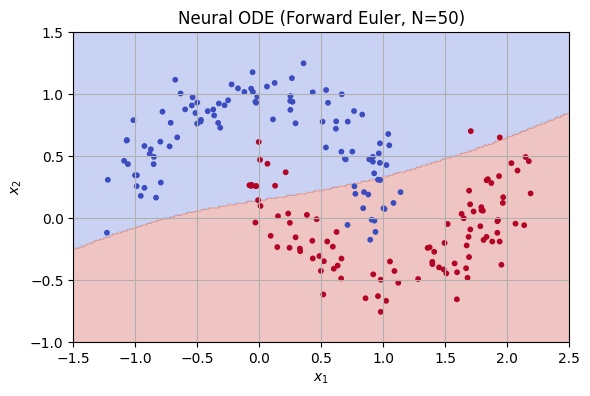

In [90]:
# creating a grid of points
xx, yy = np.meshgrid(np.linspace(-1.5, 2.5, 200), np.linspace(-1.0, 1.5, 200))

# combining the grid into shape (num_points, 2) and converting to a PyTorch tensor
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

# predicting class labels for each point in the grid
with torch.no_grad():
    zz = model(grid).argmax(1).numpy().reshape(xx.shape)

# plot the decision boundary as a filled contour plot
plt.contourf(xx, yy, zz, cmap="coolwarm", alpha=0.3)

# scatter plot of the test data with color indicating true labels
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap="coolwarm", s=10)

plt.title(f"Neural ODE (Forward Euler, N={N_STEPS})")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.gca().set_aspect("equal")
plt.grid(True)
plt.show()

As the results above indicate, even after 500 epochs, the performance of the Neural ODE framework remains inferior to that of the ResNet.

While training can be challenging, as seen here, Neural ODEs have been shown to perform well on certain problems, and this experiment was primarily for demonstration purposes.
 
Nevertheless, Neural ODEs offer an exciting perspective by enabling continuous-depth models and providing a flexible mathematical framework—motivating ongoing research and applications where these advantages can be impactful.

## Key Features of Neural ODEs

- **Continuous depth** — depth is represented as integration time $T$ rather than a discrete layer count.
- **Shared dynamics** — a single vector field $\mathcal{F}$ is reused at every integration step.
- **Adjoint training** — optional $O(1)$-memory gradient computation via the adjoint method.
- **Higher computational cost** — training and inference are typically slower than for fixed discrete networks.
- **Solver dependence** — the learned $\mathcal{F}$ may depend on the integrator used during training.
- **Numerical flexibility** — adaptive and higher-order ODE solvers may be employed at inference time.
- **Reversibility** — reversing the state dynamics requires stability conditions that are not always satisfied.


# References



1. He, K., Zhang, X., Ren, S., & Sun, J. (2016). Deep residual learning for image recognition. *Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition*, 770–778.
2. Chen, R. T. Q., Rubanova, Y., Bettencourt, J., & Duvenaud, D. (2018). Neural ordinary differential equations. *Advances in Neural Information Processing Systems*, 31, 6571–6583.
3. Haber, E., & Ruthotto, L. (2017). Stable architectures for deep neural networks. *Inverse Problems*, 34(1), 014004.
4. E, W. (2017). A proposal on machine learning via dynamical systems. *Communications in Mathematics and Statistics*, 5(1), 1–11.
5. Kidger, P. (2022). *On neural differential equations* (Doctoral dissertation, University of Oxford). arXiv preprint arXiv:2202.02435.